In [ ]:
import mod_loading as loader
from importlib import reload
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime
from tqdm import tqdm

from datetime import datetime
import gsw
import mod_argo
import matplotlib.pyplot as plt
from cmocean import cm as cmo

import mod_regression as mod_reg
import mod_preprocessing as mod_prep
reload(mod_reg)

import figs_pcm
import figs_regression as figs_reg
import figs_datadistributions as figs_dd

import mod_ocean
import mod_regression as mod_reg
import mod_pcm


datetag = datetime.now().strftime('%Y%m%d')

In [ ]:
datetag = datetime.now().strftime('%Y%m%d')

In [4]:
foo = xr.open_dataset('/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/working-vars/mapping/pco2_ocean_timemean_plevel0.nc')
foo

<xarray.Dataset>
Dimensions:     (latitude: 720, longitude: 1440, pressure: 1)
Coordinates:
  * latitude    (latitude) float64 -90.0 -89.75 -89.5 ... 89.25 89.5 89.75
  * longitude   (longitude) float64 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * pressure    (pressure) float64 0.0
Data variables:
    largescale  (latitude, longitude, pressure) float64 ...
    mse         (latitude, longitude, pressure) float64 ...
    smallscale  (latitude, longitude, pressure) float64 ...
    timemean    (latitude, longitude, pressure) float64 ...
Attributes: (12/18)
    description:              Time-mean largescale, smallscale, mse
    pressureindex:            0
    number_of_harmonics:      2
    filename:                 pangeo-argo-eke/SongPCO2/largescale_mean/ws500_...
    datafile:                 pangeo-argo-eke/data/SongPCO2/pco2_southern_oce...
    total_time:               25.41385769844055
    ...                       ...
    parent_store_largescale:  pangeo-argo-eke/SongPCO2/TIMEMEAN_largescale/ws...
    parent_store_smallscale:  pangeo-argo-eke/SongPCO2/nu32/TIMEMEAN_smallsca...
    created_date_combined:    2026-02-17T22:26:31.485129
    plevel:                   0
    largescale_file:          pangeo-argo-eke/SongPCO2/TIMEMEAN_largescale/ws...
    smallscale_file:          pangeo-argo-eke/SongPCO2/nu32/TIMEMEAN_smallsca...

In [43]:
foo.to_dataframe().describe()

,largescale,mse,smallscale,timemean
count,535520.000000,534468.000000,1.036800e+06,535520.000000
mean,353.208117,123.662401,1.938858e-02,353.245654
std,158.185918,247.510198,1.000212e+00,158.191273
min,-786.016640,-1120.033887,-4.081543e+01,-786.546909
25%,355.901938,53.446038,0.000000e+00,355.901938
50%,381.725740,70.664588,0.000000e+00,381.784681
75%,396.565391,95.370348,0.000000e+00,396.751682
max,676.127058,2122.637613,6.531227e+01,676.127058


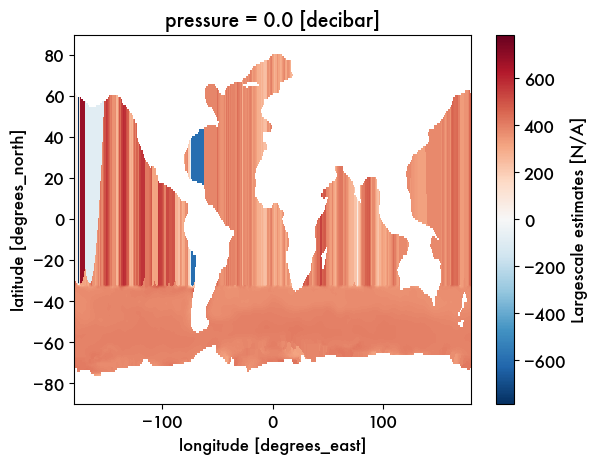

In [15]:
foo.largescale.plot()

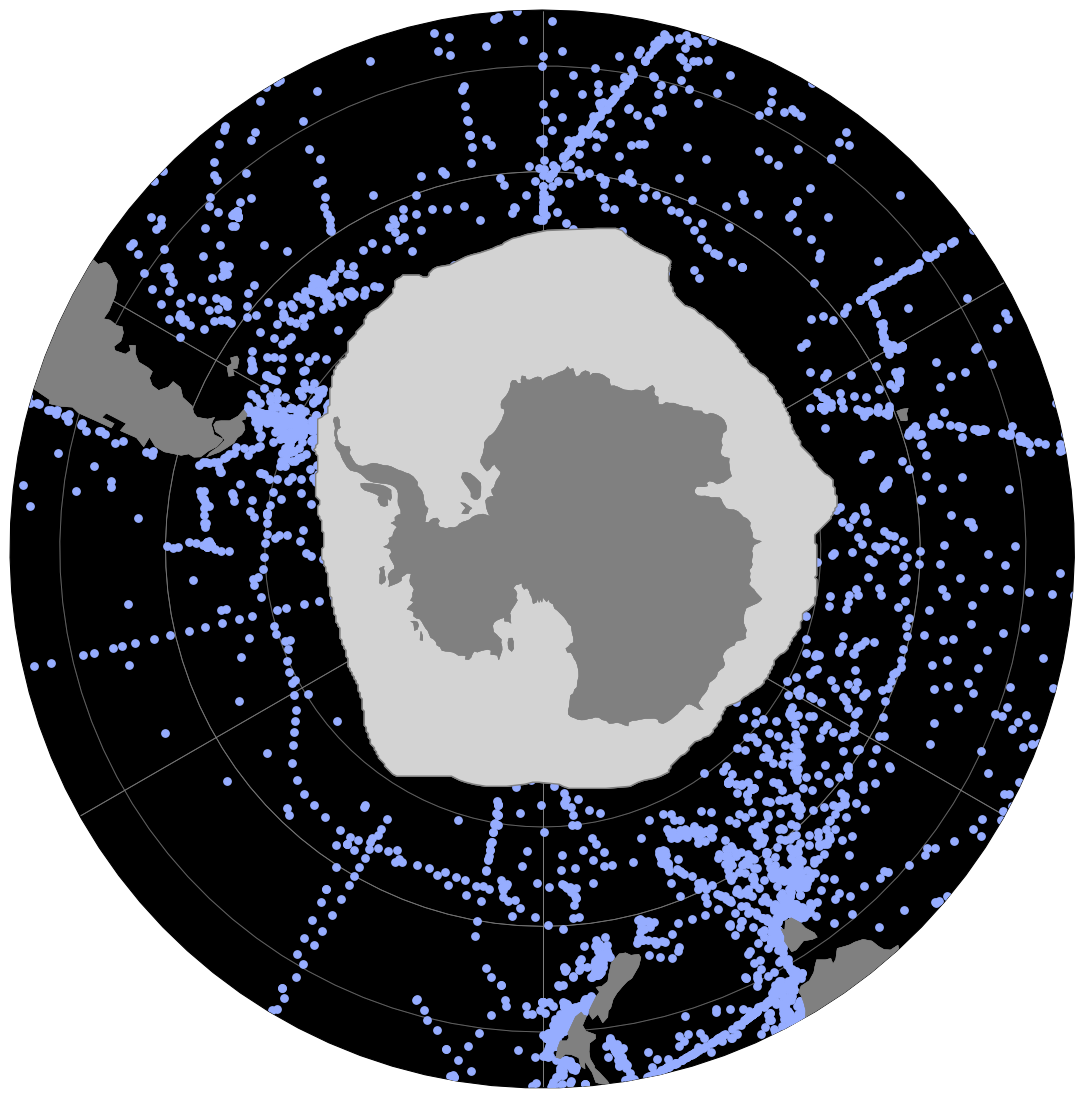

In [105]:
plt.rcParams.update(mod_plot.my_params(16))


fig = plt.figure(figsize=(14,14))
ax = plt.subplot(projection=ccrs.SouthPolarStereo())

sopo.format_southpolar(ax, map_facecolor='k',
                       land_facecolor='gray')


plot_data = trainvalDF[~trainvalDF.cruiseid.isna()].copy()
sopo.map_platformDF(plot_data, ax=ax, figsize=(9,9), dotsize=28, markerscale=3, dotalpha=1, dotcolor=figs_dd.plat_colors['socat'], label='')

# # plot_data = trainvalDF[~trainvalDF.wmoid.isna()].copy()
# sopo.map_platformDF(plot_data, ax=ax, figsize=(9,9), dotsize=28, markerscale=3, dotalpha=0.8, dotcolor=figs_dd.plat_colors['bgc'], label='')


ax.set_facecolor('k')

# sopo.add_frontlines(ax, types=['sie']) 

# Plot points first for comparison

In [68]:
import mod_plotting as mod_plot
import cartopy.crs as ccrs
import mod_southpolarplot as sopo

In [69]:
[trainvalDF, coreDF, testDF] = loader.import_p3_trainval(pcm_desc = 'pc8_gmm6_excludeClass5')

12813 profiles in trainvalDF_all (2014-2023);  270177 profiles in coreDF (2014-2023)
1807 profiles in testDF (2024 bgcArgo)


In [190]:
mapcar['rmse'] = np.sqrt(mapcar.mse)

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/core/computation.py:761: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


In [73]:
pointcollection = loader.import_p4_pointobs(pcm_desc = 'pc8_gmm6_excludeClass5')
pointcollection

/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/src/mod_loading.py:275: DtypeWarning: Columns (9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  pointDF = pd.read_csv(folder + filename, index_col=0)


,latitude,longitude,datetime,pco2_atmos,pco2_ocean,platform,profid,wmoid,cruiseid,sampleid
0,-54.804867,101.440247,2020-12-02 12:42:09.999999744,400.395969,396.669514,core_estimated,5905452_id032,5905452.0,NaN,NaN
1,-68.382812,-105.603377,2018-08-08 05:42:00.999999744,397.104769,405.752004,core_estimated,5905080_id054,5905080.0,NaN,NaN
2,-43.155000,52.657000,2015-08-30 04:08:29.000000000,400.145783,392.654236,core_estimated,1901222_id245,1901222.0,NaN,NaN
3,-55.760595,72.276247,2017-11-22 06:40:00.000000000,403.420617,404.422710,core_estimated,6902735_id148,6902735.0,NaN,NaN
4,-58.362000,129.778000,2020-01-03 22:13:29.000000000,399.002407,385.039140,core_estimated,5905073_id135,5905073.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6134,-39.536095,163.007950,2023-07-30 12:49:30,410.441585,371.927784,socatv2024,NaN,NaN,PAT520230724,PAT520230724_2023073012
6135,-37.704690,154.236000,2023-07-31 14:31:00,411.361558,366.040624,socatv2024,NaN,NaN,PAT520230724,PAT520230724_2023073114
6136,-38.579580,149.005500,2023-08-01 11:59:00,411.463255,367.773796,socatv2024,NaN,NaN,PAT520230724,PAT520230724_2023080111
6137,-37.193580,177.575300,2023-10-15 15:56:30,415.097406,351.474244,socatv2024,NaN,NaN,PAT520231011,PAT520231011_2023101515


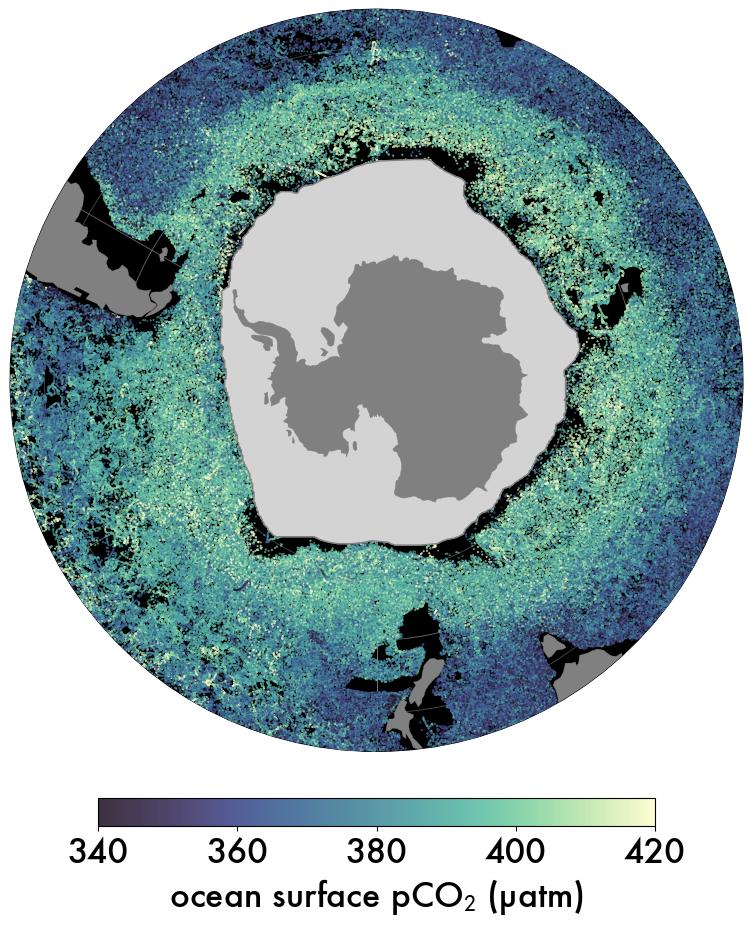

In [188]:
plt.rcParams.update(mod_plot.my_params(24))


fig = plt.figure(figsize=(10,10), layout='tight')
ax = plt.subplot(projection=ccrs.SouthPolarStereo())

sopo.format_southpolar(ax, map_facecolor= 'k', #'lightgray',
                       land_facecolor='gray')



platDF = pointcollection.copy()
# sopo.map_platformDF(pointcollection, ax=ax, 
dotsize=0.2
markerscale=3
dotalpha=0.9
dotcolor= pointcollection['pco2_ocean']    #figs_dd.plat_colors['socat'], 
label=''
# vmin=310
# vmax=430
vmin=340
vmax=420
     
mp = ax.scatter(platDF.longitude, platDF.latitude, alpha=dotalpha, s=dotsize, 
            transform=ccrs.PlateCarree(), zorder=10, cmap=cmo.deep_r,
            label=(label), c=dotcolor, vmin=vmin, vmax=vmax)

# ax.add_patch(sopo.fronts_patch('sie')) #sie


plt.colorbar(mp, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6, label='ocean surface pCO$_2$ (µatm)')
sopo.add_frontlines(ax, types=['sie']) 


# socat only
# plot_data = trainvalDF[~trainvalDF.cruiseid.isna()].copy()
# sopo.map_platformDF(plot_data, ax=ax, figsize=(9,9), dotsize=16, markerscale=3, dotalpha=1, 
#                     dotcolor= plot_data.    #figs_dd.plat_colors['socat'], 
#                     label='')


# sopo.add_frontlines(ax, types=['sie']) 

# Plot mapped product

In [9]:
import mod_southpolarplot as sopo
import cartopy.crs as ccrs

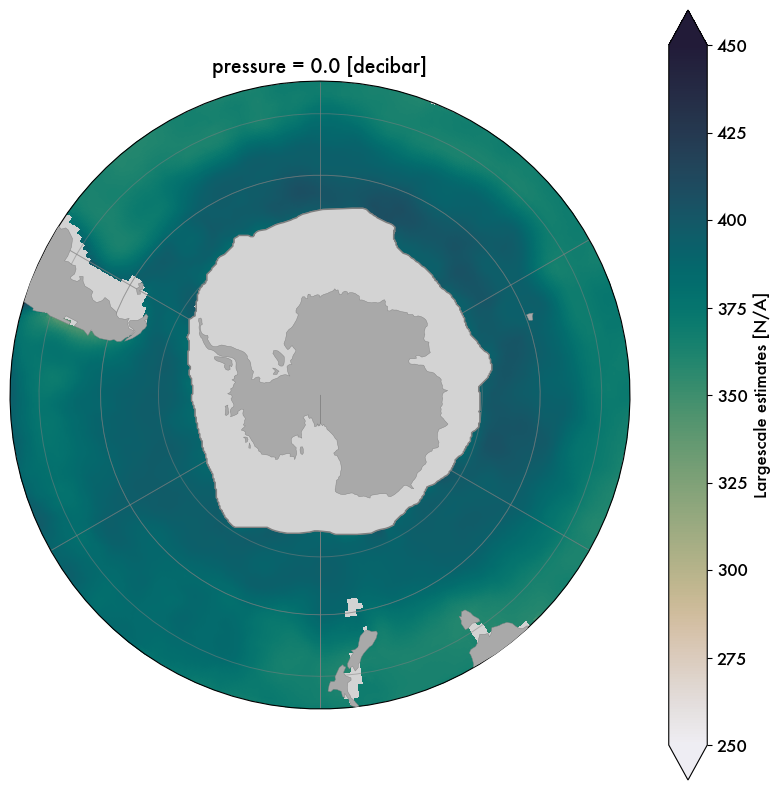

In [ ]:
fig = plt.figure(figsize=(10,10))
ax = plt.subplot(projection=ccrs.SouthPolarStereo())

sopo.format_southpolar(ax, map_facecolor='lightgray',
                       land_facecolor='darkgray')
foo.largescale.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmo.rain, add_colorbar=True, zorder=1, 
                    vmin=250, vmax=450)
sopo.add_frontlines(ax, types=['sie'])

Text(0.5, 1.0, '')

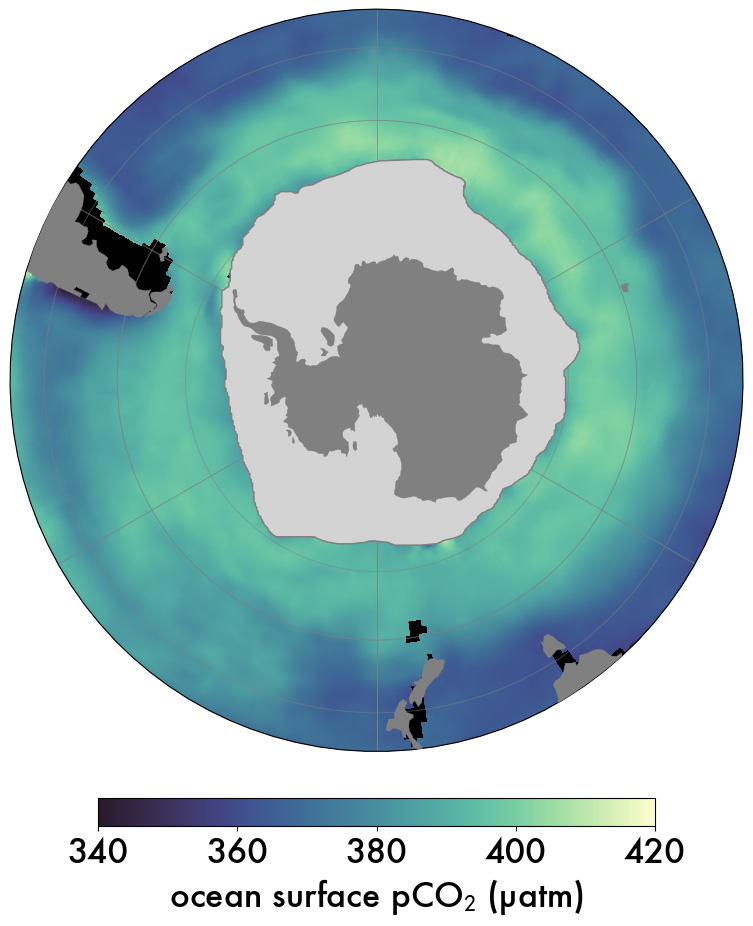

In [186]:
mapcar = foo.copy()
mapcar['pco2_ocean'] = foo.largescale + foo.smallscale

plt.rcParams.update(mod_plot.my_params(24))
fig = plt.figure(figsize=(10,10), layout='tight')
ax = plt.subplot(projection=ccrs.SouthPolarStereo())

sopo.format_southpolar(ax, map_facecolor='k',
                       land_facecolor='gray')
mp = mapcar['pco2_ocean'].plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmo.deep_r, add_colorbar=False, zorder=1, 
                    vmin=340, vmax=420)
plt.colorbar(mp, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6, label='ocean surface pCO$_2$ (µatm)')
sopo.add_frontlines(ax, types=['sie']) 
# sopo.add_frontlines(ax, types = ['stf', 'saf', 'pf', 'sacc', 'sie'])

ax.set_title('')

Text(0.5, 1.0, '')

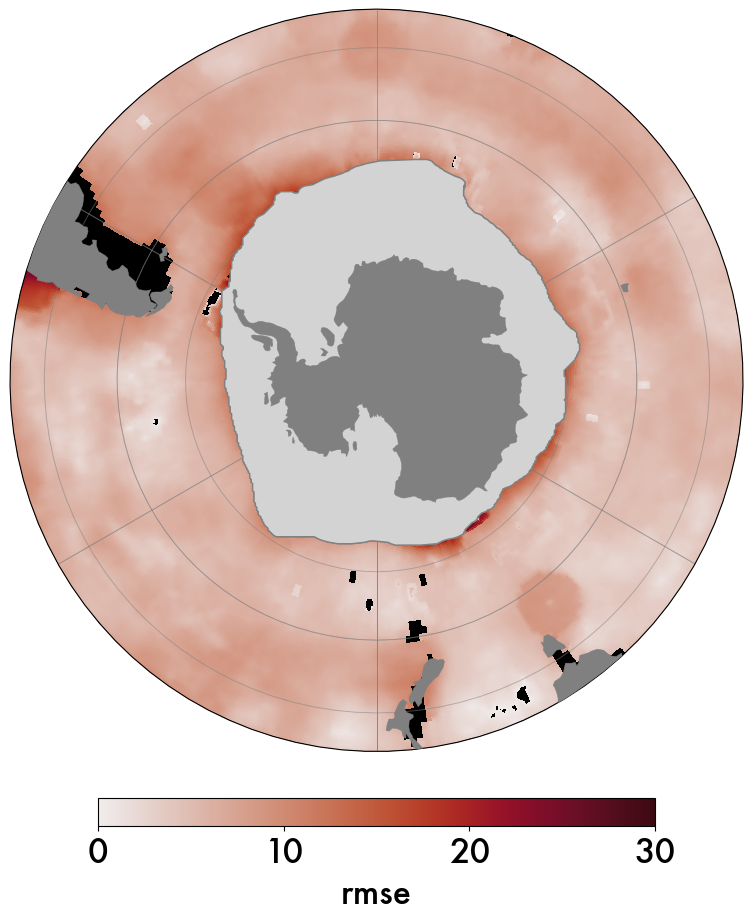

In [193]:

plt.rcParams.update(mod_plot.my_params(24))
fig = plt.figure(figsize=(10,10), layout='tight')
ax = plt.subplot(projection=ccrs.SouthPolarStereo())

sopo.format_southpolar(ax, map_facecolor='k',
                       land_facecolor='gray')
mp = mapcar['rmse'].plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmo.amp, add_colorbar=False, zorder=1, 
                    vmin=0, vmax=30) #, vmax=420)
plt.colorbar(mp, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6, label='rmse')
sopo.add_frontlines(ax, types=['sie']) 
# sopo.add_frontlines(ax, types = ['stf', 'saf', 'pf', 'sacc', 'sie'])

ax.set_title('')

In [106]:
monthly_clim = xr.open_dataset('/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/working-vars/mapping/pco2_monthly_climatology_plevel0.nc')
monthly_clim

<xarray.Dataset>
Dimensions:     (month: 12, latitude: 241, longitude: 1440, pressure: 1)
Coordinates:
  * latitude    (latitude) float64 -90.0 -89.75 -89.5 ... -30.5 -30.25 -30.0
  * longitude   (longitude) float64 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * pressure    (pressure) float64 0.0
  * month       (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    largescale  (month, latitude, longitude, pressure) float64 ...
    mse         (month, latitude, longitude, pressure) float64 ...
    pco2        (month, latitude, longitude, pressure) float64 ...
    smallscale  (month, latitude, longitude, pressure) float64 ...
Attributes:
    description:   Monthly climatology (12 months) averaged over full period
    time_start:    2014-01-16T12:00:00.000000000
    time_end:      2023-12-16T12:00:00.000000000
    ntime:         120
    parent_store:  pangeo-argo-eke/SongPCO2/monthly_timeseries_version0_ws500...
    created_date:  2026-02-19T12:42:51.087873

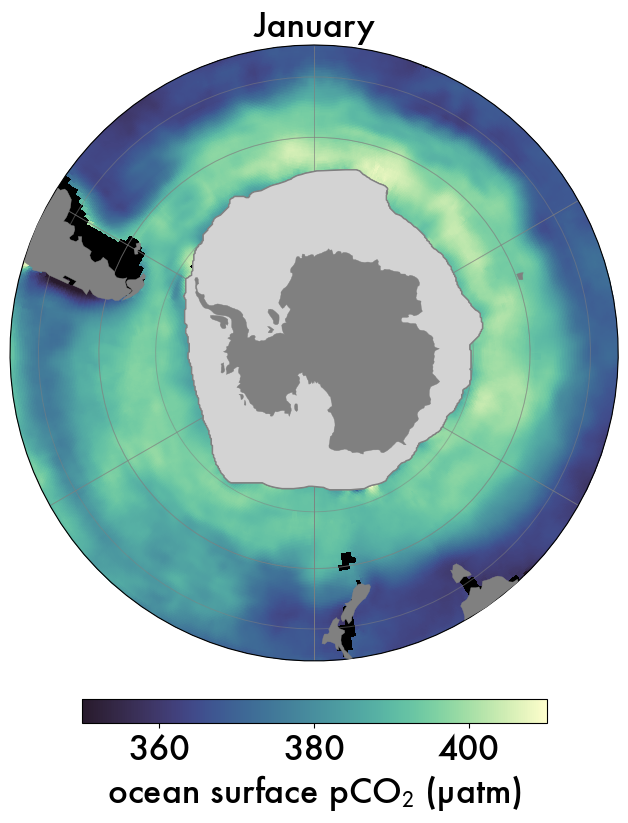

In [ ]:
mapcar = monthly_clim.copy()
mapcar['pco2_ocean'] = foo.largescale + foo.smallscale

# ===== set up plot
plt.rcParams.update(mod_plot.my_params(24))
fig = plt.figure(figsize=(10,10))
ax = plt.subplot(projection=ccrs.SouthPolarStereo())

sopo.format_southpolar(ax, map_facecolor='k',
                       land_facecolor='gray')

mapcar = mapcar.sel(month=1)
mp = mapcar['pco2_ocean'].plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmo.deep_r, add_colorbar=False, zorder=1, 
                    vmin=340, vmax=420)

plt.colorbar(mp, ax=ax, orientation='horizontal', pad=0.05, aspect=20, shrink=0.6, label='ocean surface pCO$_2$ (µatm)')
ax.set_title('January', fontsize=24)
sopo.add_frontlines(ax, types=['sie']) 

In [113]:

monthly_clim['pco2_ocean'] = monthly_clim.largescale + monthly_clim.smallscale

In [165]:
file_path = '../animation/'
fname = 'monthly_clim_acc20260219_month'
savefig = True

plt.rcParams.update(mod_plot.my_params(24))
monthlist = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
seasonlist = ['Summer', 'Summer', 'Fall', 'Fall', 'Fall', 'Winter', 'Winter', 'Winter', 'Spring', 'Spring', 'Spring', 'Summer']
# === monthly climatology data
# mapcar = monthly_clim.copy()
# monthly_clim['pco2_ocean'] = monthly_clim.largescale + monthly_clim.smallscale


# === set up loop plot
for monthnum in range(1,13):
        
    fig = plt.figure(figsize=(10,10))
    ax = plt.subplot(projection=ccrs.SouthPolarStereo())

    sopo.format_southpolar(ax, map_facecolor='k',
                        land_facecolor='gray',
                        max_latitude=-35)

    mapcar = monthly_clim.sel(month=monthnum)
    mp = mapcar['pco2_ocean'].plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmo.deep_r, add_colorbar=False, zorder=1, 
                        vmin=340, vmax=420)

    plt.colorbar(mp, ax=ax, orientation='horizontal', pad=0.05, aspect=20, shrink=0.6, label='ocean surface pCO$_2$ (µatm)')

    # Choose labels
    # ax.set_title(monthlist[monthnum-1], fontsize=24)
    ax.set_title(seasonlist[monthnum-1], fontsize=24)


    sopo.add_frontlines(ax, types=['sie']) 
        
    if savefig:
        plt.savefig(file_path + fname + str(monthnum).zfill(2) + '.png', format='png')
        # print('saved')
        plt.close()

In [143]:
str(3).zfill(2)

'03'

In [154]:
duration = 400

/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_91512/3362508316.py:14: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imagestack.append(iio.imread(file_path))


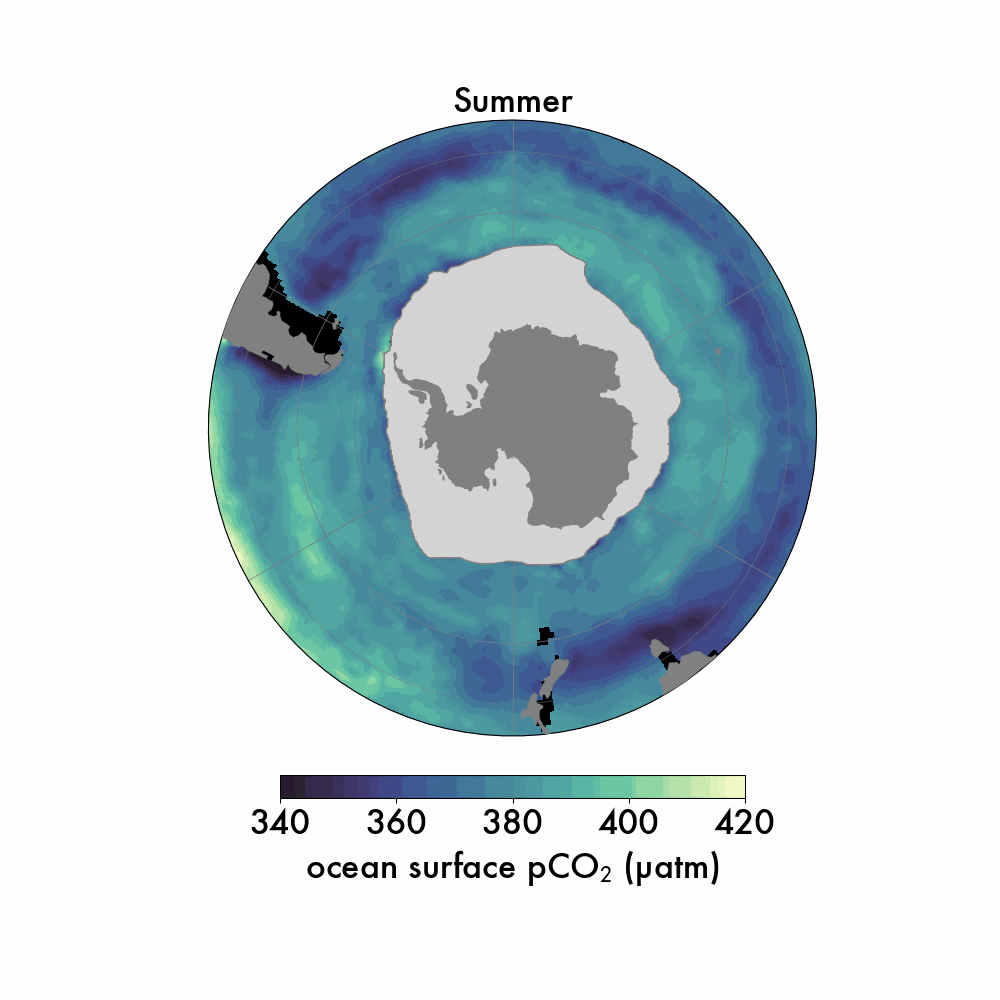

In [166]:
from IPython.display import Image
import os
import imageio as iio


gifname = 'monthly_pco2_ocean_clim_labelSeason'
png_dir = '../animation/'
fname = 'monthly_clim_acc20260219_month'

imagestack = []
for file_name in sorted(os.listdir(png_dir)):
    if file_name.startswith(fname):
        file_path = os.path.join(png_dir, file_name)
        imagestack.append(iio.imread(file_path))

# Make it pause at the end 
# for _ in range(1):
#     imagestack.append(iio.imread(file_path))

# Save them as frames into a gif 
exportname = png_dir + gifname + 'movie.gif'
kargs = { 'duration': duration, 'loop':0 }
iio.mimsave(exportname, imagestack, 'GIF', **kargs)

Image(png_dir + gifname + 'movie.gif') 
# Image(png_dir + 'adt_movie.gif')